# Coursework Set Week 5

**Common remarks**:

* Deadline: Sunday at 23:59h for the scheduled week of this task
* <font color='red'>Keep all the information in this template unaltered!</font>

**Please fill in the following fields:**

* Name: Bálint Dobák
* Username: bdobak
* Student number: S6398154
* Group (AS1, etc.): AS3

-----

In [1]:
totalpoints = currentpoints = 0

### Plotting a galaxy rotation curve from data in a text file (4 pt) <font color='red'><b>COURSEWORK</b></font>

This qustion you will use data from an observation of NGC 6946. The stellar mass of NGC 6946 is $M_* = 2\times10^{10} M_{\odot}$, where $M_{\odot}$ represent *solar mass (the mass of the Sun)*. 

* Copy/download the file [rotcur.dat](https://www.astro.rug.nl/intranet/courses/PROGNUMNEW/latest/DATA/rotcur.dat). This text file contains the output of a program that calculates rotation curves. Examine its contents on the Linux command line with a pager like ``more`` or in an editor so that you know what the columns represent.
* Write a program, that reads the columns `radius` and `rotation velocity`. Radii are in **kpc** and velocities in **km/s**.
* Create a line plot where the $x$-axis represents the radius and the $y$-axis represents the rotation velocity.
* Calculate the Keplerian rotation curve using $v=\sqrt{\frac{GM}{r}}$
* Create and save a text file called ``keplerian_curve.txt`` using ``np.savetxt()``.
* Using ``np.loadtxt()`` to load your Keplerian curve and plot it together with the observation data.
* Force the lower limit of the $y$-axis range to 0 and the upper limit to maximal values of the Keplerian curve.
* Annotate the plot with relevant information.
* Make comment about your observation.

**Answers**:

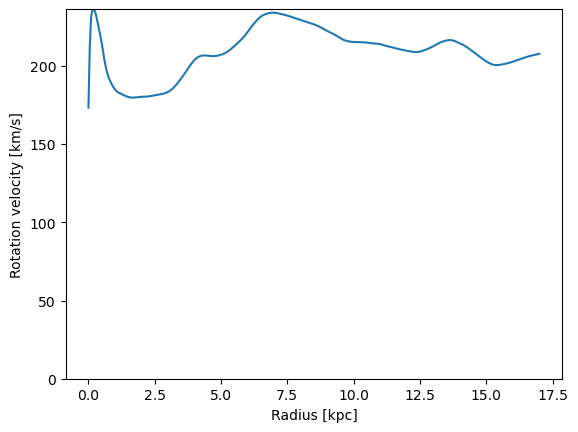

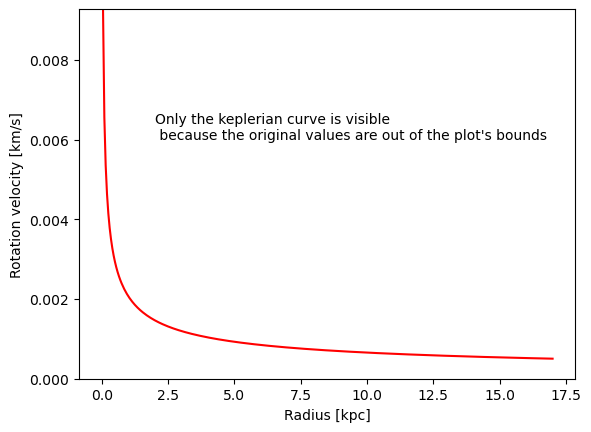

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.constants import G, M_sun
g=G.value
M=M_sun.value
#plotting the rotation curve
rad, vel=np.loadtxt('rotcur.dat.txt',unpack=True) #It is a txt file on my computer for some reason
plt.plot(rad, vel)
plt.xlabel('Radius [kpc]')
plt.ylabel('Rotation velocity [km/s]')
plt.ylim(0,vel.max())
plt.show()
#creating the keplerian curve
rad2=rad[rad>0]*(3.086*10**19)
kvel=(g*M/rad2)**0.5
data=np.column_stack((rad2,kvel))
np.savetxt('keplerian_curve.txt',data)
radnew,velnew=np.loadtxt('keplerian_curve.txt',unpack=True)
radnew/=(3.086*10**19)
velnew/=1000
plt.plot(radnew,velnew,color='r')
plt.plot(rad, vel,color='b')
plt.xlabel('Radius [kpc]')
plt.ylabel('Rotation velocity [km/s]')
plt.ylim(0,velnew.max())
plt.annotate("Only the keplerian curve is visible \n because the original values are out of the plot's bounds",(2.0,0.006))
plt.show()
#Observation: the keplerian curve differs a lot from the measured one, so this provides support for the presence of dark matter

In [3]:
# Leave unaltered
totalpoints += 4
currentpoints += 0.0

### Exploring image noise (3 pt)  <font color='red'><b>COURSEWORK</b></font>
   
* Create a two dimensional NumPy array with 200 rows and 300 columns filled with pixel values drawn from the normal distribution ``numpy.random.normal()`` with a mean of 0 and standard deviation 1.0.
* Use ``plt.imshow()`` to plot the image. The figure must be 8 inches wide and 4 inches high.
* Use color map ``jet`` for your image.
* Take a small two dimensional slice (e.g. 30x30 pixels) somewhere in the image and calculate the mean and standard deviation of the pixel values in your slice.
* Are this mean and standard deviation what you expected?
* Plot a histogram of all image values in 50 bins (you will need to ravel/flatten the data first). To not overlap with the previous plot, you probably need to create a new plot ``plt.figure()``. What distribution should you recognise?

**Answer**:

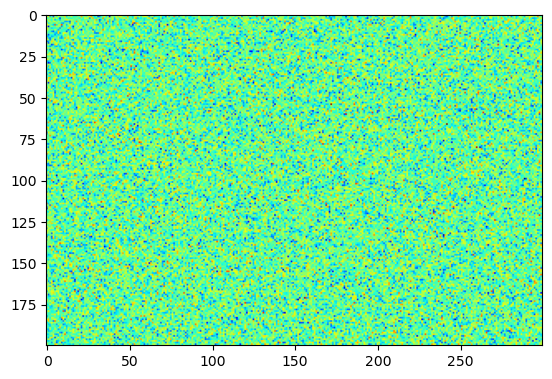

<Figure size 800x400 with 0 Axes>

mean=-0.09374739521234438 and std=0.9795311412044536 are very close to 0 and 1 which is what we expected
This is a normal distribution


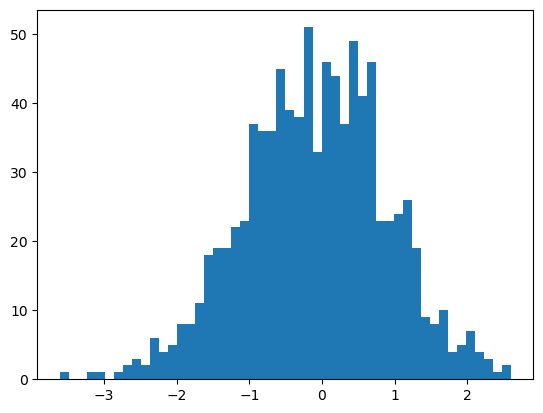

In [4]:
#creating the array
a=np.random.normal(0,1,200*300)
a=a.reshape(200,300)
#making the plot
plt.imshow(a, cmap='jet')
plt.figure(figsize=[8,4])
plt.show()
#30x30 slice
b=a[50:80,100:130]
std=b.std()
mean=b.mean()
print(f"mean={mean} and std={std} are very close to 0 and 1 which is what we expected")
#making the histogram
c=b.flatten()
plt.figure()
plt.hist(c,bins=50)
print("This is a normal distribution")

In [5]:
# Leave unaltered
totalpoints += 3
currentpoints += 0.0

### Extending the Ellipse class (6 pt) <font color='red'><b>COURSEWORK</b></font>

* Copy the code for class ``AstroEllipse`` in the section.
* Extend the class with a method that calculates and returns the area of the ellipse.
* Extend the class with a method that calculates and returns the perimeter of the ellipse (keywords: Ramanujan’s formula for perimeter of ellipse).
* Give an example of the creation of an ellipse with semi major axis equal to 3 and semi minor axis equal to 2 and call the methods for area and perimeter to show what the area and perimeter is for this ellipse.
* Add a method ``__str__()`` which returns a string with the values of the ellipse parameters (center, axes and angle) and demonstrate the method with ``print()``.
* Create a class ``MyCircle`` which inherits from class ``AstroEllipse``. The arguments for its ``__init__()`` function is a center position and a radius.
* Create a plot with three circles with random origins and radii. The circles must have different colors and the  transparency (``alpha=``) must be set to 0.5. Use the ``Axes`` object (Section 5.7) to add the circles to the plot.

**Answers**:

18.84955592153876 15.865437575563961
Center: (0,0) Semi major axis: 3 Semi minor axis: 2 Position angle: 0


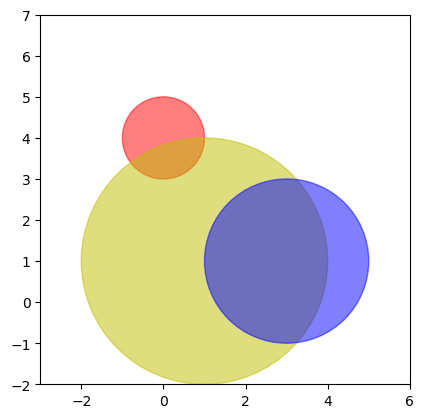

In [6]:
from matplotlib.patches import Ellipse
from matplotlib.pyplot import figure, show
class AstroEllipse(Ellipse):
    from scipy.constants import pi
    def __init__(self, xc, yc, semi_major, semi_minor, position_angle, **args):
      # We use the (sort of) astronomical angle where 'angle' defines)
      # the position angle of the major axis of a ring projected onto the sky
      # (i.e. an ellipse). This is an angle taken in anti-clockwise direction between
      # the north direction on the sky and the major axis of the receding half of the
      # galaxy (Rots 1975, astron, astrophys 45, 43).
      # Here we assume (!) north is in the positive Y direction.
      # If not, you need to correct the angle for the rotation of the image.
      # Parameter 'position_angle' enters in degrees
      assert(semi_major >= semi_minor)  # Prerequisite to make angle unambiguous
      XY = (xc, yc)                  # MPL requires center as a tuple
      angle_mpl = position_angle     # Angle for MatPlotLib's ellipse patch
      height = 2.0*semi_major        # height: is along vertical axis for an unrotated ellipse
      width  = 2.0*semi_minor        # width:  is along horizontal axis for an unrotated ellipse
      self.a=semi_major
      self.b=semi_minor
      self.pa=position_angle
      self.x=xc
      self.y=yc
      super().__init__(XY, width, height, angle=angle_mpl, **args)
    def area(self):
      A=self.a*self.b*self.pi
      return A
    def perimeter(self):
        P=self.pi*(3*(self.a+self.b)-((3*self.a+self.b)*(self.a+3*self.b))**0.5) #Ramanujan approximation
        return P
    def __str__(self):
        return f"Center: ({self.x},{self.y}) Semi major axis: {self.a} Semi minor axis: {self.b} Position angle: {self.pa}"

class MyCircle(AstroEllipse):

    def __init__(self,x,y,r,**args):
        super().__init__(x,y,r,r,0,**args)
#testing the functions        
ell=AstroEllipse(0,0,3,2,0)
print(ell.area(), ell.perimeter())
print(ell)

#creating the plot
fig=figure()
frame=fig.add_subplot(1,1,1)
x=np.random.randint(0,5,3)
y=np.random.randint(0,5,3)
r=np.random.randint(1,5,3)
c1=MyCircle(x[0],y[0],r[0],color='r',alpha=0.5)
c2=MyCircle(x[1],y[1],r[1],color='y',alpha=0.5)
c3=MyCircle(x[2],y[2],r[2],color='b',alpha=0.5)
frame.add_patch(c1)
frame.add_patch(c2)
frame.add_patch(c3)
#to make sure that everything is in frame
frame.set_xlim(x.min()-r.max(),x.max()+r.max())
frame.set_ylim(y.min()-r.max(),y.max()+r.max())
frame.set_aspect('equal')
show()

In [7]:
# Leave unaltered
totalpoints += 6
currentpoints += 0.0

### Plotting Bessel's function (3 pt) <font color='red'><b>COURSEWORK</b></font>
   
The differential equation of Bessel is:

$$x^2\ \frac{d^2y}{dx^2}+x\ \frac{dy}{dx}+(x^2-a^2)y=0$$

Solutions of this equation are called Bessel functions of the first kind of real order ``a``.
Bessel functions are especially important for problems of wave propagation and static 
potentials and in solutions to the radial Schrodinger equation in quantum mechanics. 

Module ``special`` in package SciPy provides Bessel functions with the import statement:

```python
from scipy.special import jv
```

Write code that plots a solution of Bessel's differential equation for ``a=1,2,3`` and ``a=4`` on the interval ``x=[0,10]``in a mosaic of 2x2 plots. A Bessel function has arguments: ``jv(a, x)`` 

<font color='red'>Note: Object Oriented Plotting is required, or 1.0pt will be deducted.</font>

* Annotate your plot with a title and labels for the $x$- and $y$ axis. 
* Add a legend with labels for all curves.
* Include code that saves your figure to a file with base name ``bessel`` as a transparent PNG file.
* Attach the figure (PNG file) in the notebook.

**Code and figure**:

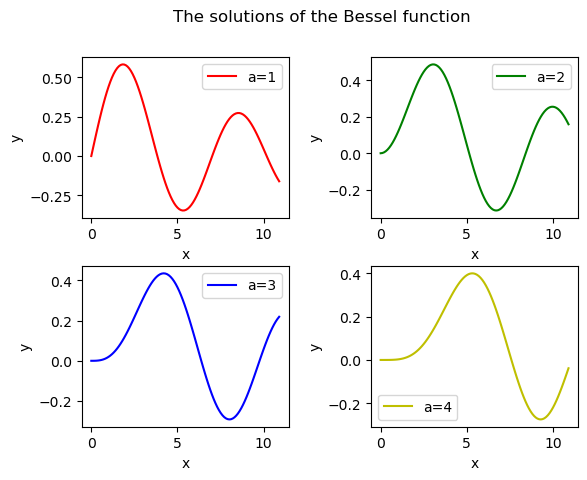

In [8]:
from scipy.special import jv
from matplotlib.pyplot import figure, show

#creating the data
x=np.arange(0,11,0.1)
y=[]
for i in range(1,5):
    y.append(jv(i,x))
y=np.array(y)

#making the subplots
colors=['r','g','b','y']
fig=figure()
for i in range(4):
    frame=fig.add_subplot(2,2,i+1)
    frame.plot(x,y[i,:],color=colors[i],label=f"a={i+1}")
    frame.legend()
    frame.set_xlabel("x")
    frame.set_ylabel("y")
fig.suptitle("The solutions of the Bessel function")
fig.subplots_adjust(wspace=0.4, hspace=0.3)
#saving the figure
fig.savefig('bessel.png',transparent=True)
show()

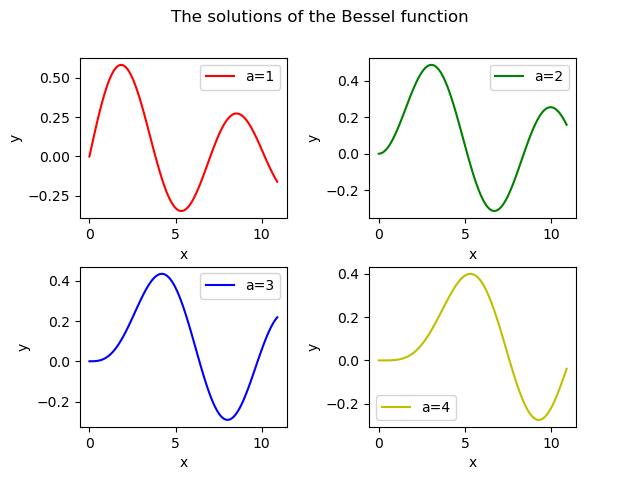

In [9]:
# Leave unaltered
totalpoints += 3
currentpoints += 0.0

### Matplotlib, the right way (2 pt)  <font color='red'><b>HOMEWORK</b></font>

The following table contains the measurements of distances and velocities, including their uncertainties, for a small sample of galaxies. The table is given in the form of a Python list.

From your previous coursework, you have done chi-squared fitting to fit the following data without uncertainties. If considering the uncertainties during the fitting process, the slope of a best fit line through the data gives a value for the Hubble constant.

$$H_0 = 67.8 (km/s)/Mpc$$

```
    d(Mpc)    v(km/s)    error in d    error in v
    ==============================================
    18.49      2094.75    0.3           100
    35.48      2320.87    2.2           120
    ........
```
```python
    data = [
    18.49,     2094.75,    0.3,           100,
    35.48,     2320.87,    2.2,           120,
    35.48,     1224.9,     3.0,           80,
    11.34,     872.13,     1.2,           80,
    7.12,      432.2,      0.4,           70,
    9.82,      751,        0.3,           75,
    23.66,     1410,       2.3,           70,
    44,        2700,       4.0,           110,
    66.7,      5292,       5.3,           120,
    52.4,      2550,       5.2,           100,
    55,        5253,       6.1,           150,
    25.6,      2419,       3.2,           110,
    26.19,     2158,       2.8,           110
    ]
```

<font color='red'>In this question, you have to use the OO interface of Matplotlib to create your plot, or 1.0pt will be deducted.</font>

* Use slicing syntax to unpack ``data`` into separate variables for distance and velocity, as well as their corresponding errors.
* Create a plot for this data. Add error bars with method `errorbar() <matplotlib.axes.Axes.errorbar>`
* Plot also a line which represents the Hubble relation between distance and velocity  as a line through the origin, with a slope equal to $H_0$
* Add the value of $H_0$ to the legend using LaTex math mode
  
**Script and plot**:

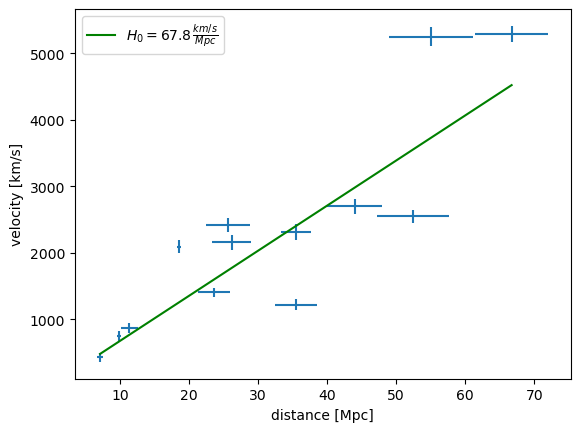

In [10]:
data = [
    18.49,     2094.75,    0.3,           100,
    35.48,     2320.87,    2.2,           120,
    35.48,     1224.9,     3.0,           80,
    11.34,     872.13,     1.2,           80,
    7.12,      432.2,      0.4,           70,
    9.82,      751,        0.3,           75,
    23.66,     1410,       2.3,           70,
    44,        2700,       4.0,           110,
    66.7,      5292,       5.3,           120,
    52.4,      2550,       5.2,           100,
    55,        5253,       6.1,           150,
    25.6,      2419,       3.2,           110,
    26.19,     2158,       2.8,           110
    ]

#slicing the data
data=np.array(data)
d=data[0::4]
v=data[1::4]
errd=data[2::4]
errv=data[3::4]

#making the plot
fig=figure()
frame=fig.add_subplot(1,1,1)
frame.errorbar(d,v,xerr=errd,yerr=errv, fmt='none')
frame.plot([d.min(),d.max()], [d.min()*67.8,d.max()*67.8],color='g',label=r'$H_0=67.8 \, \frac{km/s}{Mpc}$')
frame.set_xlabel("distance [Mpc]")
frame.set_ylabel("velocity [km/s]")
frame.legend(loc='upper left')
show()

In [11]:
# Leave unaltered
totalpoints += 2
currentpoints += 0.0

## Finishing up

**Please read the section about your report in the task documentation very carefully before submitting it to BrightSpace.**

------------

## T.A. Grading


In [12]:
# Leave unaltered
taskgrade = round(10*currentpoints/totalpoints, 1) if totalpoints != 0 else 0
print(f"Total number of points: {totalpoints}. Student score: {currentpoints}.  Task Grade = {taskgrade}")

Total number of points: 18. Student score: 0.0.  Task Grade = 0.0
